In [1]:
# IMPORTS
import numpy as np
import pandas as pd
import requests


#Fin Data Sources
import yfinance as yf
import pandas_datareader as pdr

#Data viz
import plotly.graph_objs as go
import plotly.express as px

import time
from datetime import date

# for graphs
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

url = "https://stockanalysis.com/ipos/withdrawn/"


headers = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/58.0.3029.110 Safari/537.3'
    )
}

response = requests.get(url, headers=headers)
response.raise_for_status()

tables = pd.read_html(response.text)

/tmp/ipykernel_33295/2888363439.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


In [3]:
tables

[   Symbol                Company Name      Price Range Shares Offered
 0    ODTX  Odyssey Therapeutics, Inc.                -              -
 1    UNFL      Unifoil Holdings, Inc.    $3.00 - $4.00        2000000
 2    AURN        Aurion Biotech, Inc.                -              -
 3    ROTR             PHI Group, Inc.                -              -
 4     ONE           One Power Company                -              -
 ..    ...                         ...              ...            ...
 95    FHP   Freehold Properties, Inc.                -              -
 96    CHO                Chobani Inc.                -              -
 97   IFIT  iFIT Health & Fitness Inc.  $18.00 - $21.00       30769231
 98   GLGX  Gerson Lehrman Group, Inc.                -              -
 99    HCG               hear.com N.V.  $17.00 - $20.00       16220000
 
 [100 rows x 4 columns],
      Date Symbol                 Name
 0  Jun 23   HCHL  Happy City Holdings
 1  Jun 24   FMFC     Kandal M Venture
 2  

In [4]:
tables[0]

,Symbol,Company Name,Price Range,Shares Offered
0,ODTX,"Odyssey Therapeutics, Inc.",-,-
1,UNFL,"Unifoil Holdings, Inc.",$3.00 - $4.00,2000000
2,AURN,"Aurion Biotech, Inc.",-,-
3,ROTR,"PHI Group, Inc.",-,-
4,ONE,One Power Company,-,-
...,...,...,...,...
95,FHP,"Freehold Properties, Inc.",-,-
96,CHO,Chobani Inc.,-,-
97,IFIT,iFIT Health & Fitness Inc.,$18.00 - $21.00,30769231
98,GLGX,"Gerson Lehrman Group, Inc.",-,-


In [5]:
withdrawn = tables[0]

In [6]:
type(withdrawn)

pandas.core.frame.DataFrame

In [7]:
withdrawn.dtypes

Symbol            object
Company Name      object
Price Range       object
Shares Offered    object
dtype: object

In [8]:
withdrawn.head()

,Symbol,Company Name,Price Range,Shares Offered
0,ODTX,"Odyssey Therapeutics, Inc.",-,-
1,UNFL,"Unifoil Holdings, Inc.",$3.00 - $4.00,2000000
2,AURN,"Aurion Biotech, Inc.",-,-
3,ROTR,"PHI Group, Inc.",-,-
4,ONE,One Power Company,-,-


In [9]:
withdrawn.tail()

,Symbol,Company Name,Price Range,Shares Offered
95,FHP,"Freehold Properties, Inc.",-,-
96,CHO,Chobani Inc.,-,-
97,IFIT,iFIT Health & Fitness Inc.,$18.00 - $21.00,30769231
98,GLGX,"Gerson Lehrman Group, Inc.",-,-
99,HCG,hear.com N.V.,$17.00 - $20.00,16220000


In [28]:
import re

def classify_company(name):
    # Eliminar comas, puntos y convertir en palabras
    words = re.findall(r'\b\w+\b', name.lower())  # sólo palabras, sin puntuación

    if "acquisition" in words and ("corp" in words or "corporation" in words):
        return "Acq.Corp"
    elif "inc" in words or "incorporated" in words:
        return "Inc"
    elif "group" in words:
        return "Group"
    elif "ltd" in words or "limited" in words:
        return "Limited"
    elif "holdings" in words:
        return "Holdings"
    else:
        return "Other"

withdrawn["Company Class"] = withdrawn["Company Name"].apply(classify_company)


In [29]:
withdrawn.head(10)

,Symbol,Company Name,Price Range,Shares Offered,Company Class
0,ODTX,"Odyssey Therapeutics, Inc.",-,-,Inc
1,UNFL,"Unifoil Holdings, Inc.",$3.00 - $4.00,2000000,Inc
2,AURN,"Aurion Biotech, Inc.",-,-,Inc
3,ROTR,"PHI Group, Inc.",-,-,Inc
4,ONE,One Power Company,-,-,Other
5,HPOT,The Great Restaurant Development Holdings Limited,$4.00 - $6.00,1400000,Limited
6,CABR,"Caring Brands, Inc.",$4.00,750000,Inc
7,SQVI,"Sequoia Vaccines, Inc.",$8.00 - $10.00,2775000,Inc
8,SNI,Shenni Holdings Limited,$4.00 - $6.00,3000000,Limited
9,KMCM,Key Mining Corp.,$2.25,4444444,Other


In [30]:
withdrawn["Company Class"].value_counts()

Company Class
Inc         51
Acq.Corp    21
Limited     17
Other        6
Group        4
Holdings     1
Name: count, dtype: int64

In [34]:
search_term = "oldings"
withdrawn[withdrawn["Company Name"].str.contains(search_term, case=False, na=False)]


,Symbol,Company Name,Price Range,Shares Offered,Company Class
1,UNFL,"Unifoil Holdings, Inc.",$3.00 - $4.00,2000000,Inc
5,HPOT,The Great Restaurant Development Holdings Limited,$4.00 - $6.00,1400000,Limited
8,SNI,Shenni Holdings Limited,$4.00 - $6.00,3000000,Limited
27,AMGS,Prospect Energy Holdings Corp.,$10.00,7500000,Holdings
29,DRFY,Droneify Holdings Limited,$6.00 - $7.00,923077,Limited
35,VEG,Veg House Holdings Inc.,$5.00,1000000,Inc
58,JR,Jinrong Holdings Ltd.,$5.00,-,Limited
69,BTNC,Bridgetown 3 Holdings Limited,$10.00,20000000,Limited
80,DEFY,"Agora Digital Holdings, Inc.",-,-,Inc


In [36]:
withdrawn

,Symbol,Company Name,Price Range,Shares Offered,Company Class
0,ODTX,"Odyssey Therapeutics, Inc.",-,-,Inc
1,UNFL,"Unifoil Holdings, Inc.",$3.00 - $4.00,2000000,Inc
2,AURN,"Aurion Biotech, Inc.",-,-,Inc
3,ROTR,"PHI Group, Inc.",-,-,Inc
4,ONE,One Power Company,-,-,Other
...,...,...,...,...,...
95,FHP,"Freehold Properties, Inc.",-,-,Inc
96,CHO,Chobani Inc.,-,-,Inc
97,IFIT,iFIT Health & Fitness Inc.,$18.00 - $21.00,30769231,Inc
98,GLGX,"Gerson Lehrman Group, Inc.",-,-,Inc


In [37]:
def parse_avg_price(price_range):
    if isinstance(price_range, str):
        # Eliminar símbolos de dólar y espacios
        clean = price_range.replace("$", "").replace(" ", "")
        
        # Caso 1: rango de dos precios
        if "-" in clean:
            try:
                low, high = map(float, clean.split("-"))
                return round((low + high) / 2, 2)
            except:
                return None

        # Caso 2: precio único
        try:
            return float(clean)
        except:
            return None

    # Caso 3: valor nulo o guion
    return None

# Aplicar la función
withdrawn["Avg. Price"] = withdrawn["Price Range"].apply(parse_avg_price)


In [40]:
withdrawn.tail(10)

,Symbol,Company Name,Price Range,Shares Offered,Company Class,Avg. Price
90,DSTY,Dynasty Financial Partners Inc.,-,-,Inc,NaN
91,ALOHA,"Cariloha, Inc.",$9.00 - $11.00,2000000,Inc,10.0
92,DPAC,Deep Space Acquisition Corp. I,$10.00,21000000,Acq.Corp,10.0
93,GIF,"GigCapital6, Inc.",$10.00,20000000,Inc,10.0
94,HYIV,Haymaker Acquisition Corp. IV,$10.00,26100000,Acq.Corp,10.0
95,FHP,"Freehold Properties, Inc.",-,-,Inc,NaN
96,CHO,Chobani Inc.,-,-,Inc,NaN
97,IFIT,iFIT Health & Fitness Inc.,$18.00 - $21.00,30769231,Inc,19.5
98,GLGX,"Gerson Lehrman Group, Inc.",-,-,Inc,NaN
99,HCG,hear.com N.V.,$17.00 - $20.00,16220000,Other,18.5


In [39]:
withdrawn.dtypes

Symbol             object
Company Name       object
Price Range        object
Shares Offered     object
Company Class      object
Avg. Price        float64
dtype: object

In [41]:
withdrawn["Shares Offered"].value_counts(dropna=False)

Shares Offered
-           28
20000000     9
7500000      4
2000000      3
3750000      3
1500000      2
2250000      2
1400000      2
10000000     2
30000000     2
15000000     2
25000000     2
18000000     2
1250000      2
3000000      2
750000       1
1200000      1
1333334      1
2106250      1
3500000      1
2500000      1
2775000      1
4444444      1
1095000      1
1000000      1
2300000      1
923077       1
1600000      1
2900000      1
500000       1
2625000      1
45000000     1
1300000      1
2651000      1
14500000     1
1150000      1
1333333      1
3726709      1
21687082     1
1270000      1
1350000      1
4190476      1
35000000     1
17500000     1
21000000     1
26100000     1
30769231     1
16220000     1
Name: count, dtype: int64

In [42]:
withdrawn.dtypes

Symbol             object
Company Name       object
Price Range        object
Shares Offered     object
Company Class      object
Avg. Price        float64
dtype: object

In [43]:
withdrawn["Shares Offered"] = pd.to_numeric(withdrawn["Shares Offered"], errors="coerce")

In [44]:
withdrawn.tail(10)

,Symbol,Company Name,Price Range,Shares Offered,Company Class,Avg. Price
90,DSTY,Dynasty Financial Partners Inc.,-,NaN,Inc,NaN
91,ALOHA,"Cariloha, Inc.",$9.00 - $11.00,2000000.0,Inc,10.0
92,DPAC,Deep Space Acquisition Corp. I,$10.00,21000000.0,Acq.Corp,10.0
93,GIF,"GigCapital6, Inc.",$10.00,20000000.0,Inc,10.0
94,HYIV,Haymaker Acquisition Corp. IV,$10.00,26100000.0,Acq.Corp,10.0
95,FHP,"Freehold Properties, Inc.",-,NaN,Inc,NaN
96,CHO,Chobani Inc.,-,NaN,Inc,NaN
97,IFIT,iFIT Health & Fitness Inc.,$18.00 - $21.00,30769231.0,Inc,19.5
98,GLGX,"Gerson Lehrman Group, Inc.",-,NaN,Inc,NaN
99,HCG,hear.com N.V.,$17.00 - $20.00,16220000.0,Other,18.5


In [45]:
withdrawn["Withdrawn Value"] = withdrawn["Shares Offered"] * withdrawn["Avg. Price"]

In [48]:
withdrawn["Withdrawn Value"].notna().sum()

np.int64(71)

In [49]:
withdrawn

,Symbol,Company Name,Price Range,Shares Offered,Company Class,Avg. Price,Withdrawn Value
0,ODTX,"Odyssey Therapeutics, Inc.",-,NaN,Inc,NaN,NaN
1,UNFL,"Unifoil Holdings, Inc.",$3.00 - $4.00,2000000.0,Inc,3.5,7000000.0
2,AURN,"Aurion Biotech, Inc.",-,NaN,Inc,NaN,NaN
3,ROTR,"PHI Group, Inc.",-,NaN,Inc,NaN,NaN
4,ONE,One Power Company,-,NaN,Other,NaN,NaN
...,...,...,...,...,...,...,...
95,FHP,"Freehold Properties, Inc.",-,NaN,Inc,NaN,NaN
96,CHO,Chobani Inc.,-,NaN,Inc,NaN,NaN
97,IFIT,iFIT Health & Fitness Inc.,$18.00 - $21.00,30769231.0,Inc,19.5,600000004.5
98,GLGX,"Gerson Lehrman Group, Inc.",-,NaN,Inc,NaN,NaN


In [50]:
grouped = (
    withdrawn.groupby("Company Class")["Withdrawn Value"]
    .sum()
    .reset_index()
    .sort_values(by="Withdrawn Value", ascending=False)
)

print(grouped)


  Company Class  Withdrawn Value
0      Acq.Corp     4.021000e+09
3           Inc     2.257164e+09
5         Other     7.679200e+08
4       Limited     5.497346e+08
2      Holdings     7.500000e+07
1         Group     3.378750e+07


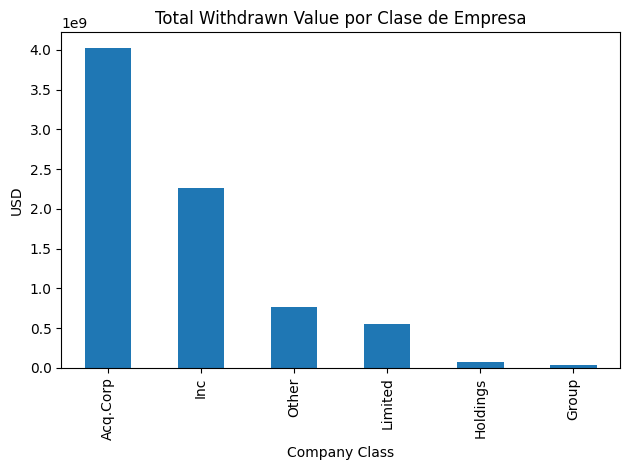

In [51]:
import matplotlib.pyplot as plt

grouped.plot(
    kind="bar",
    x="Company Class",
    y="Withdrawn Value",
    legend=False,
    title="Total Withdrawn Value por Clase de Empresa"
)
plt.ylabel("USD")
plt.tight_layout()
plt.show()


In [52]:
grouped_millions = (
    withdrawn.groupby("Company Class")["Withdrawn Value"]
    .sum()
    .div(1_000_000)  # <-- convierte a millones
    .reset_index(name="Withdrawn Value (M)")
    .sort_values(by="Withdrawn Value (M)", ascending=False)
)

print(grouped_millions)


  Company Class  Withdrawn Value (M)
0      Acq.Corp          4021.000000
3           Inc          2257.164205
5         Other           767.919999
4       Limited           549.734585
2      Holdings            75.000000
1         Group            33.787500


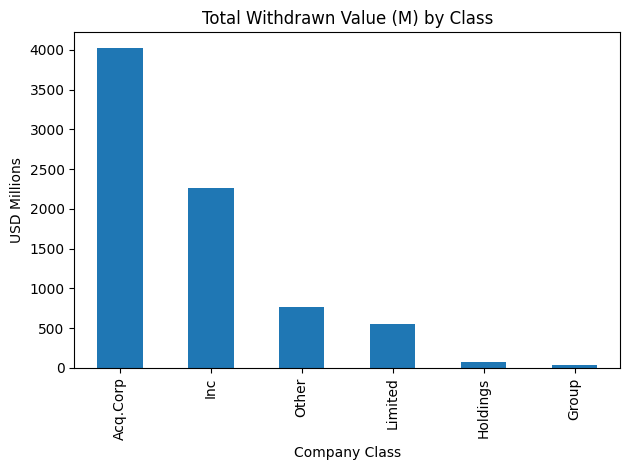

In [55]:
grouped_millions.plot(
    kind="bar",
    x="Company Class",
    y="Withdrawn Value (M)",
    legend=False,
    title="Total Withdrawn Value (M) by Class"
)
plt.ylabel("USD Millions")
plt.tight_layout()
plt.show()